# Deskriptiv statistikk: Målinger, variasjon og usikkerhet

```{admonition} Læringsutbytte
Etter å ha arbeidet med dette temaet, skal du kunne:

1. forklare hvorfor gjentatte kjemiske målinger varierer
2. velge mellom gjennomsnitt og median i enkle kjemiske situasjoner
3. forklare hva persentiler og interkvartilbredde forteller oss
4. bruke standardavvik og relativt standardavvik til å beskrive presisjon
5. skille mellom standardavvik, standardfeil og konfidensintervall
6. beregne og tolke et 95 % konfidensintervall for en middelverdi
```

Når vi gjentar en kjemisk måling, får vi sjelden nøyaktig samme resultat. Vi kan for eksempel måle jernkonsentrasjonen i den samme løsningen fem ganger og få følgende data:

In [7]:
measurements_mg_L = [5.12, 5.08, 5.15, 5.10, 5.13]

Forskjellene er små, men de er der. De kan blant annet skyldes instrumentstøy, små forskjeller i volum eller temperatur og variasjon i prøveprepareringen. Statistikk hjelper oss med å beskrive denne variasjonen. Den kan også hjelpe oss med å vurdere hva målingene samlet sier om konsentrasjonen.

I dette kapitlet skal vi derfor følge to spørsmål:

1. **Hvor ligger målingene?** Det beskriver vi med for eksempel gjennomsnitt eller median.
2. **Hvor mye varierer de?** Det beskriver vi med for eksempel standardavvik eller interkvartilbredde.

Hvilke størrelser vi bør bruke, avhenger av hva slags data vi har. Det kommer vi tilbake til flere ganger.

## Hva er det vi har målt?

Ofte svarer statistikk på ulike spørsmål, avhengig av hva og hvordan vi har målt. Vi kan blant annet skille mellom to typer datasett som er vanlige i kjemi:

- **Gjentatte målinger av samme prøve.** Her er det ofte naturlig å beskrive resultatet med gjennomsnitt og standardavvik.
- **Målinger fra mange forskjellige prøver.** Konsentrasjoner i ulike jord-, vann- eller blodprøver kan være skjevt fordelt. Da er median og interkvartilbredde ofte mer informative.

Dette er ikke absolutte regler, men de gir et godt utgangspunkt.

## Hvor ligger målingene?

### Gjennomsnitt

```{admonition} Gjennomsnitt
Gjennomsnittet er summen av alle observasjonene delt på antall observasjoner.
```

Det kan skrives slik:

$$
\bar{x}=\frac{x_1+x_2+\cdots+x_n}{n}
$$

In [9]:
import numpy as np

mean = np.mean(measurements_mg_L)
print(f"Mean: {mean:.3f} mg/L")

Mean: 5.116 mg/L


For måleserien vår blir gjennomsnittet 5,116 mg/L. Gjennomsnittet bruker informasjon fra alle målingene. Det passer derfor godt når vi har gjentatte målinger av samme homogene prøve, og variasjonen ser noenlunde symmetrisk ut.

Samtidig gjør dette gjennomsnittet følsomt for svært lave eller høye verdier. Én feilpipettering kan flytte gjennomsnittet merkbart.

### Median

```{admonition} Median
Medianen er den midterste verdien når dataene er sortert. Ved et partall observasjoner bruker vi gjennomsnittet av de to midterste verdiene.
```



In [10]:
median = np.median(measurements_mg_L)
print(f"Median: {median:.3f} mg/L")


Median: 5.120 mg/L


Medianen påvirkes mindre av ekstreme verdier. Den er derfor nyttig når fordelingen er skjev, eller når vi skal beskrive et datasett med enkelte svært høye eller lave observasjoner.

Tenk for eksempel på nitratkonsentrasjonen i vannprøver fra mange bekker. De fleste bekkene kan ha lave verdier, mens noen få bekker nær jordbruksområder har mye høyere konsentrasjon. Da kan medianen beskrive en typisk bekk bedre enn gjennomsnittet.

````{admonition} Underveisoppgave
:class: tip
Sammenlikn disse to måleseriene:

```{code-block} Python
measurements_1 = np.array([10.02, 10.05, 9.98, 10.01, 10.04])
measurements_2 = np.array([10.02, 10.05, 9.98, 10.01, 10.42])

for measurements in [measurements_1, measurements_2]:
    print("Mean:", np.mean(measurements))
    print("Median:", np.median(measurements))
```
Hvilken størrelse påvirkes mest når den siste verdien endres?

```{admonition} Løsningsforslag
:class: tip, dropdown
Gjennomsnittet påvirkes mest fordi alle verdiene inngår direkte i beregningen. Medianen er 10,02 mg/L i begge seriene. Dette viser at medianen er mer robust. Det viser ikke at 10,42 mg/L automatisk kan fjernes; årsaken til den høye verdien må undersøkes.
```
````

## Persentiler: plassering i en fordeling

For å forstå interkvartilbredde må vi først forstå persentiler.

```{admonition} Persentil
En persentil er en grenseverdi i et sortert datasett. For eksempel er 25-persentilen en verdi som omtrent 25 % av observasjonene ligger på eller under.
```

- 25-persentilen er en verdi der omtrent 25 % av observasjonene ligger på eller under.
- 50-persentilen er medianen. Omtrent halvparten ligger på eller under.
- 75-persentilen er en verdi der omtrent 75 % ligger på eller under.

En persentil er altså **ikke** en prosent av den største verdien. Den beskriver en plassering i fordelingen.

Vi ser på nitratkonsentrasjoner fra tolv bekker:



In [11]:
nitrate_mg_L = np.array([
    0.42, 0.47, 0.50, 0.55, 0.58, 0.61,
    0.65, 0.72, 0.85, 1.10, 1.35, 2.80,
])

q1 = np.percentile(nitrate_mg_L, 25)
median = np.percentile(nitrate_mg_L, 50)
q3 = np.percentile(nitrate_mg_L, 75)

print(f"25th percentile: {q1:.2f} mg/L")
print(f"Median: {median:.2f} mg/L")
print(f"75th percentile: {q3:.2f} mg/L")


25th percentile: 0.54 mg/L
Median: 0.63 mg/L
75th percentile: 0.91 mg/L


Her er 25-persentilen omtrent 0,54 mg/L. Det betyr at omtrent en fjerdedel av målingene/bekkene har en nitratkonsentrasjon på 0,54 mg/L eller lavere. Medianen er 0,63 mg/L, mens 75-persentilen er omtrent 0,91 mg/L.

Med få observasjoner ligger ikke persentilen alltid på en av verdiene i datasettet. Programmet kan da beregne en verdi mellom to observasjoner. Det finnes flere regler for denne beregningen, så ulike programmer kan gi litt forskjellige svar for små datasett. Tolkningen er likevel den samme.

```{admonition} Kjemisk bruk av persentiler
Persentiler brukes ofte når vi vil beskrive hvordan konsentrasjoner fordeler seg i mange prøver. En 95-persentil for et forurensende stoff kan for eksempel brukes til å beskrive et høyt nivå som bare omtrent 5 % av prøvene overskrider.
```

## Hvor mye varierer dataene?

### Variasjonsbredde

```{admonition} Variasjonsbredde
Variasjonsbredden er forskjellen mellom den største og den minste observasjonen i datasettet.
```

In [ ]:
data_range = np.max(nitrate_mg_L) - np.min(nitrate_mg_L)
print(f"Range: {data_range:.2f} mg/L")

Range: 2.38 mg/L


Variasjonsbredden er enkel å forstå, men den bestemmes av bare to observasjoner. Én svært høy verdi kan derfor gjøre den stor. Vi bruker den gjerne til en rask oversikt, men sjelden som det eneste målet på spredning.

### Interkvartilbredde

Første kvartil, $Q_1$, er 25-persentilen. Tredje kvartil, $Q_3$, er 75-persentilen. Området mellom dem inneholder de midterste 50 % av observasjonene.

```{admonition} Interkvartilbredde (IQR)
Interkvartilbredden er avstanden fra 25-persentilen ($Q_1$) til 75-persentilen ($Q_3$). Den beskriver dermed spredningen i de midterste 50 % av observasjonene.
```

$$
IQR=Q_3-Q_1
$$



In [24]:
iqr = q3 - q1
print(f"IQR: {iqr:.2f} mg/L")

IQR: 0.37 mg/L


For nitratdataene er IQR omtrent 0,37 mg/L. Den høyeste verdien på 2,80 mg/L påvirker variasjonsbredden kraftig, men påvirker IQR langt mindre. Derfor rapporteres IQR ofte sammen med medianen når dataene er skjeve.

Et boksplott bygger på de samme størrelsene:



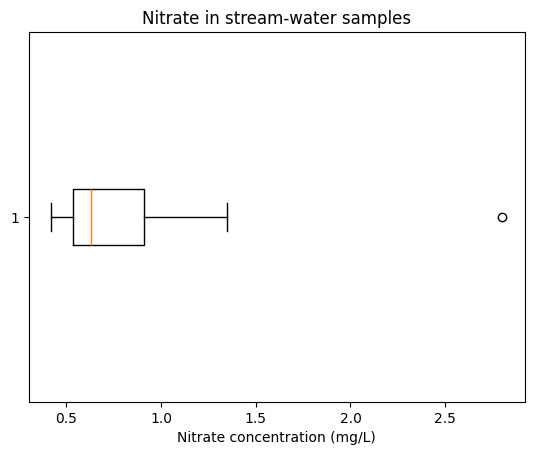

In [25]:
import matplotlib.pyplot as plt

plt.boxplot(nitrate_mg_L, vert=False)
plt.xlabel("Nitrate concentration (mg/L)")
plt.title("Nitrate in stream-water samples")
plt.show()

Vi kan forklare dette plottet slik:

- Den svarte linja midt i boksen er medianen.
- 50 \% av verdiene ligger innenfor boksen. Boksen markerer altså interkvartilområdet, fra $Q_1$ til $Q_3$.
- Vi har to utstikkere (såkalte "værhår") på hver side av boksen. De viser $IQR\cdot1.5 = 1.5(Q_3 - Q_1)$ i begge retninger. Faktoren 1.5 er bare en konvensjon, og vi kan i utgangspunktet lage boksplott som viser spredning på en annen måte.
- Verdier som ligger utenfor disse utstikkerne, kalles _utliggere_. Dette er unormalt store eller små verdier. Vi må undersøke disse nærmere med statistisk analyse for å eventuelt kunne fjerne dem.

### Standardavvik

```{admonition} Standardavvik
Standardavviket beskriver den typiske spredningen til enkeltmålingene rundt gjennomsnittet. Det har samme enhet som målingene.
```

For et utvalg beregnes det slik:

$$
s=\sqrt{\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}}
$$

Formelen kan se omfattende ut, men ideen er enkel: Vi finner avstanden fra hver måling til gjennomsnittet og samler disse avstandene i ett mål på spredning. Standardavviket får samme enhet som målingene.

In [ ]:
sample_sd = np.std(measurements_mg_L, ddof=1)
print(f"Sample SD: {sample_sd:.3f} mg/L")

Sample SD: 0.027 mg/L


Argumentet `ddof=1` gjør at NumPy deler på $n-1$. Det bruker vi når målingene våre er et utvalg av alle målingene vi kunne ha gjort (såkalt _empirisk standardavvik_). For jernmålingene er standardavviket omtrent 0,027 mg/L.

Standardavvik passer særlig godt sammen med gjennomsnittet når vi har gjentatte målinger av samme prøve, og målingene ligger noenlunde symmetrisk rundt gjennomsnittet. Det påvirkes, som gjennomsnittet, av ekstreme verdier.

```{admonition} Hva betyr tallet?
Et standardavvik på 0,027 mg/L betyr ikke at alle målingene ligger nøyaktig 0,027 mg/L fra gjennomsnittet. Det er en samlet beskrivelse av den typiske spredningen i måleserien.
```

### Relativt standardavvik

```{admonition} Relativt standardavvik (RSD)
Relativt standardavvik er standardavviket uttrykt som prosent av gjennomsnittet. Det gjør det lettere å sammenlikne relativ presisjon ved ulike målenivåer.
```

$$
RSD=\frac{s}{\bar{x}}\cdot100\ \%
$$

In [27]:
rsd_percent = sample_sd / mean * 100
print(f"RSD: {rsd_percent:.2f} %")

RSD: 0.53 %


RSD brukes mye til å beskrive og sammenlikne presisjon i kjemiske analysemetoder. Et standardavvik på 0,10 mg/L er lite dersom konsentrasjonen er 100 mg/L, men stort dersom konsentrasjonen er 0,20 mg/L. RSD setter spredningen i forhold til målenivået.

RSD er lite egnet når gjennomsnittet ligger nær null. Da kan en liten absolutt variasjon gi en svært stor prosentverdi.

## Hva bruker vi når?

| Situasjon | Nyttige størrelser | Kjemisk eksempel |
|---|---|---|
| Gjentatte målinger av samme homogene prøve, omtrent symmetrisk fordelt | Gjennomsnitt og standardavvik | Fem uavhengig preparerte løsninger av samme prøve analyseres med UV–Vis |
| Mange ulike prøver med skjev fordeling | Median og interkvartilbredde | Nitrat i bekker eller metallinnhold i jordprøver fra mange steder |
| Sammenlikne presisjon ved ulike konsentrasjonsnivåer | RSD | Sammenlikne repeterbarhet ved 1 mg/L og 100 mg/L |
| Raskt se hele spennvidden | Variasjonsbredde | Første kontroll av en liten måleserie |
| Beskrive et lavt, typisk eller høyt nivå i en fordeling | Persentil | 50- og 95-persentilen for en miljøgift i mange prøver |
| Vurdere hvor presist middelverdien er bestemt | Standardfeil eller konfidensintervall | Rapportere estimert innhold i et referansemateriale |

Tabellen viser typiske valg, ikke automatiske regler. Vi bør også se på rådataene og tenke over hvordan prøvene er samlet inn.

## Fra spredning til usikkerhet i gjennomsnittet

Så langt har vi beskrevet observasjonene vi har. Ofte vil vi også bruke dem til å anslå en ukjent middelverdi. De fem jernmålingene kan for eksempel brukes til å anslå hva analysemetoden i gjennomsnitt ville gitt dersom målingen ble gjentatt mange ganger under tilsvarende betingelser.

Hvis vi gjentok hele forsøket, ville vi neppe fått nøyaktig det samme gjennomsnittet. Også gjennomsnittet varierer fra forsøk til forsøk.

### Standardfeil

```{admonition} Standardfeil
Standardfeilen beskriver hvor mye gjennomsnittet forventes å variere dersom hele forsøket gjentas mange ganger med samme antall uavhengige målinger.
```

$$
SE=\frac{s}{\sqrt{n}}
$$



In [28]:
n = len(measurements_mg_L)
standard_error = sample_sd / np.sqrt(n)

print(f"Standard error: {standard_error:.3f} mg/L")

Standard error: 0.012 mg/L


## Konfidensintervall for middelverdien

Gjennomsnittet 5,116 mg/L er det beste enkeltanslaget vårt for jernkonsentrasjonen. Men dersom vi lagde fem nye løsninger og gjorde forsøket på nytt, ville gjennomsnittet sannsynligvis blitt litt annerledes. Vi trenger derfor en måte å vise hvor usikkert dette anslaget er.

```{admonition} Konfidensintervall
Et konfidensintervall er et intervall rundt den målte middelverdien som brukes til å uttrykke hvor presist vi har bestemt den sanne middelverdien til måleprosessen.

Et **95 % konfidensintervall** beregnes med en metode som, dersom hele forsøket gjentas mange ganger, vil gi intervaller som inneholder den sanne middelverdien omtrent 95 % av gangene.
```

### Hvorfor bruker vi ofte 95 %?

Vi må velge hvor høy sikkerhet vi ønsker at intervallmetoden skal ha. Vanlige valg er 90 %, 95 % og 99 %. Et høyere konfidensnivå gir større sikkerhet for at metoden fanger den sanne middelverdien, men det har en pris: **intervallet blir bredere**.

For eksempel vil et 99 % konfidensintervall være bredere enn et 95 % konfidensintervall beregnet fra de samme målingene. Skal vi være sikrere på å treffe, må vi inkludere et større område av mulige verdier.

95 % brukes svært ofte i naturvitenskap fordi det gir et praktisk kompromiss mellom et intervall som er tilstrekkelig pålitelig og et intervall som ikke blir unødvendig bredt. Tallet 95 % er altså ikke en naturkonstant eller en spesiell kjemisk grense. Det er en **konvensjon**.

I dette kapitlet bruker vi derfor 95 % konfidensintervall dersom ikke annet er oppgitt.

### Fra standardfeil til et intervall

Vi har tidligere beregnet standardfeilen:

$$SE=\frac{s}{\sqrt{n}}$$

Standardfeilen beskriver hvor mye middelverdien forventes å variere dersom vi gjentar hele forsøket med nye målinger.

For jernmålingene våre er

$$SE\approx0{,}012\ \text{mg/L}$$

Men dette er fortsatt bare **ett tall**. Standardfeilen er ikke et intervall. For å lage et 95 % konfidensintervall må vi bestemme hvor langt vi skal gå ut fra middelverdien på hver side. Vi trenger altså en **feilmargin**:

$$\text{feilmargin}=\text{faktor}\cdot SE$$

Spørsmålet blir derfor: Hvilken faktor skal vi bruke for dette feilintervallet?

Hvis vi kjente det sanne standardavviket $\sigma$ for hele måleprosessen, kunne vi brukt normalfordelingen til å finne denne faktoren. Men i et virkelig eksperiment kjenner vi vanligvis ikke $\sigma$. Vi har bare noen få målinger og må derfor bruke standardavviket $s$ som et anslag. Det gir en ekstra usikkerhet: Ikke bare varierer middelverdien fra forsøk til forsøk, men også standardavviket vi har beregnet, er usikkert.

**Students t-fordeling tar hensyn til denne ekstra usikkerheten.**

Istedenfor å ta utgangspunkt i normalfordeling, bruker vi _Students t-fordeling_. Denne t-fordelingen ligner normalfordelingen, men har bredere haler. Det betyr at vi må gå litt lenger ut fra middelverdien for å få et intervall med samme konfidensnivå. Hvor mye lenger ut vi må gå, bestemmes av en **t-faktor**.

### Frihetsgrader

t-faktoren avhenger av hvor mange uavhengige målinger vi har. Dette uttrykkes gjennom antall **frihetsgrader**:

$$df=n-1$$

Hvorfor mister vi én frihetsgrad?

Tenk at vi har fem målinger og allerede har bestemt gjennomsnittet. Hvis vi kjenner fire av målingene og gjennomsnittet, kan ikke den femte målingen velges fritt. Den må ha akkurat den verdien som gjør at gjennomsnittet blir riktig. Når gjennomsnittet først er bestemt, er derfor bare fire av de fem avvikene fra gjennomsnittet uavhengige.

Med fem målinger får vi dermed

$$df=5-1=4$$

Jo færre frihetsgrader vi har, desto større er usikkerheten i standardavviket, og desto større blir t-faktoren. Når antall målinger _n_ blir stort, blir standardavviket mer nøyaktig. Da nærmer t-fordelingen seg normalfordelingen.

### Slik beregner vi 95 % konfidensintervallet

For jernmålingene har vi:

| Størrelse |      Verdi | Betydning                                      |
| --------- | ---------: | ---------------------------------------------- |
| $\bar{x}$ | 5,116 mg/L | målt middelverdi                               |
| $s$       | 0,027 mg/L | spredning mellom enkeltmålingene               |
| $n$       |          5 | antall uavhengige målinger                     |
| $df$      |          4 | antall frihetsgrader                           |
| $SE$      | 0,012 mg/L | standardfeilen til middelverdien               |
| $t$       |      2,776 | t-faktor for 95 % konfidens og 4 frihetsgrader |

Vi beregner først standardfeilen:

$$SE=\frac{s}{\sqrt{n}}=\frac{0{,}027}{\sqrt{5}}\approx0{,}012\ \text{mg/L}$$

For et tosidig 95 % konfidensintervall med fire frihetsgrader er t-faktoren

$$t=2{,}776$$

At intervallet er **tosidig**, betyr at vi lager en nedre og en øvre grense. De 5 prosentene som ligger utenfor intervallet fordeles derfor med 2,5 % på hver side.

Feilmarginen blir

$$\text{feilmargin}=t\cdot SE=2{,}776\cdot0{,}012\approx0{,}034\ \text{mg/L}$$

Til slutt legger vi feilmarginen på begge sider av middelverdien:

$$\bar{x}\pm\text{feilmargin}=5{,}116\pm0{,}034\ \text{mg/L}$$

Dermed får vi intervallet

$$[5{,}082,\ 5{,}150]\ \text{mg/L}$$

Hele beregningen kan samles i én formel:

$$\bar{x}\pm t\frac{s}{\sqrt{n}}$$

Her er:

* $\bar{x}$ middelverdien fra målingene
* $s$ standardavviket til enkeltmålingene
* $n$ antall uavhengige målinger
* $s/\sqrt{n}$ standardfeilen
* $t$ t-faktoren for valgt konfidensnivå og antall frihetsgrader

### Beregning med Python

Python kan gjøre de samme beregningene. Vi trenger `numpy` til gjennomsnitt, standardavvik og kvadratrot, og `scipy.stats` til å finne riktig t-faktor. I funksjonen `ppf` (percent point function) beregnes t-faktoren:

In [ ]:
import numpy as np
from scipy.stats import t

målinger = np.array([5.08, 5.12, 5.15, 5.10, 5.13])

n = len(målinger)
gjennomsnitt = np.mean(målinger)
standardavvik = np.std(målinger, ddof=1)
standardfeil = standardavvik / np.sqrt(n)

frihetsgrader = n - 1
konfidensnivå = 0.95
alpha = 1 - konfidensnivå

# 1 - alpha/2 = 97,5 % fordi vi har et tosidig intervall
t_faktor = t.ppf(1 - alpha/2, frihetsgrader)

feilmargin = t_faktor * standardfeil

nedre_grense = gjennomsnitt - feilmargin
øvre_grense = gjennomsnitt + feilmargin

print(f"Gjennomsnitt: {gjennomsnitt:.3f} mg/L")
print(f"Standardavvik: {standardavvik:.3f} mg/L")
print(f"Standardfeil: {standardfeil:.3f} mg/L")
print(f"t-faktor: {t_faktor:.3f}")
print(f"95 % konfidensintervall: [{nedre_grense:.3f}, {øvre_grense:.3f}] mg/L")

Funksjonen `t.ppf` finner en verdi i t-fordelingen. Vi bruker `0.975` fordi vi ønsker et tosidig 95 % intervall: 95 % skal ligge i midten, mens 2,5 % ligger utenfor på hver side. Den øvre grensen tilsvarer derfor 97,5 % av fordelingen.

Med fire frihetsgrader gir dette omtrent

$$t=2{,}776$$

Resten av Python-koden følger nøyaktig den samme framgangsmåten som den manuelle beregningen:

$$\text{målinger}\rightarrow s\rightarrow SE\rightarrow t\cdot SE\rightarrow\text{konfidensintervall}$$

### Hvordan skal intervallet tolkes?

Tenk deg at vi gjentar **hele forsøket** svært mange ganger. Hver gang gjør vi fem nye, uavhengige målinger og beregner et nytt 95 % konfidensintervall med akkurat den samme framgangsmåten.

Middelverdien vil variere fra forsøk til forsøk, og dermed vil også konfidensintervallet flytte på seg.

Metoden er konstruert slik at omtrent **95 % av disse intervallene vil inneholde den sanne middelverdien $\mu$**, dersom forutsetningene for beregningen er oppfylt. Omtrent 5 % vil bomme.

Det er altså framgangsmåten for å lage intervallet som har en treffrate på 95 %.

Når vi først har gjennomført forsøket og fått ett bestemt intervall, ligger den sanne middelverdien enten innenfor dette intervallet eller utenfor. Strengt tatt betyr derfor ikke et 95 % konfidensintervall at det er 95 % sannsynlighet for at $\mu$ ligger akkurat i det ferdige intervallet.

```{admonition} Hva intervallet ikke betyr
:class: caution

Et 95 % konfidensintervall er **ikke** området som inneholder 95 % av enkeltmålingene.

Standardavviket beskriver spredningen mellom enkeltmålingene. Konfidensintervallet beskriver derimot usikkerheten i **middelverdien**.

Konfidensintervallet sier heller ikke noe om systematiske feil. Dersom for eksempel kalibreringsløsningen har feil konsentrasjon, kan alle målingene bli forskjøvet i samme retning. Da kan vi få et smalt konfidensintervall rundt en middelverdi som likevel er feil.
```

## Rapportering og avrunding

Python regner med langt flere sifre enn det som vanligvis er meningsfullt å rapportere i et kjemisk måleresultat. Det er derfor viktig å skille mellom **beregningspresisjon** og **rapporteringspresisjon**.

En vanlig tommelfingerregel i kjemi er at standardavvik, standardfeil og andre usikkerhetsmål oppgis med **maks to gjeldende sifre**. Middelverdien avrundes deretter til **samme desimalplass** som usikkerheten.

| Beregnet verdi | Rapportert verdi |
|---|---|
| $5.1164 \pm 0.02736$ mg/L | $5.116 \pm 0.027$ mg/L |
| $5.1164 \pm 0.03184$ mg/L | $5.12 \pm 0.03$ mg/L |
| $5.1164 \pm 0.00347$ mg/L | $5.116 \pm 0.003$ mg/L |

Dette er en rapporteringskonvensjon, ikke en del av selve statistikkberegningen. I videre beregninger bør vi derfor beholde full presisjon så lenge som mulig og først avrunde når resultatet skal presenteres.

```{admonition} Eksempel
:class: note

Hvis Python gir

$$\bar{x}=5.1164\ \text{mg/L}, \qquad s=0.02736\ \text{mg/L}$$

kan resultatet rapporteres som

$$5.116 \pm 0.027\ \text{mg/L}$$

fordi standardavviket er avrundet til to gjeldende sifre, og middelverdien deretter er avrundet til samme desimalplass.
```


Resultatet kan rapporteres på to likeverdige måter:

$$
\bar{x}=5{,}116\ \text{mg/L},\quad 95\ \%\ \text{KI}=[5{,}082,\ 5{,}150]\ \text{mg/L}
$$

eller

$$
\bar{x}=(5{,}116\pm0{,}034)\ \text{mg/L}\quad(95\ \%\ \text{KI})
$$

Begge skrivemåtene sier at 5,116 mg/L er punktestimatet, mens intervallet viser usikkerheten i middelverdien under forutsetningene vi har brukt.

### Hva gjør intervallet smalere eller bredere?

- **Større spredning gir bredere intervall.** Når enkeltmålingene varierer mye, blir middelverdien mindre presist bestemt.
- **Flere uavhengige målinger gir vanligvis smalere intervall.** Standardfeilen avtar med $\sqrt{n}$. Fire ganger så mange målinger halverer derfor omtrent standardfeilen dersom spredningen er den samme.
- **Høyere konfidensnivå gir bredere intervall.** Et 99 % intervall må dekke flere mulige resultater enn et 95 % intervall.

Flere avlesninger er bare nyttige dersom de representerer den variasjonen vi ønsker å undersøke. Ti avlesninger av den samme kyvetten sier mindre om hele analysemetoden enn ti løsninger som er preparert uavhengig.

Du kan undersøke beregningen i editoren nedenfor.

<iframe src="../../basthon/?from=examples/statistics_confidence_interval.py" width="100%" height="700" frameborder="0" title="Interactive Python editor for a confidence interval" loading="lazy" allowfullscreen></iframe>

````{admonition} Underveisoppgave
:class: tip

1. Legg til flere målinger med omtrent samme nivå og spredning. Hva skjer med standardavviket, standardfeilen og intervallet?
2. Endre konfidensnivået til 90 % og 99 %. Hva skjer med bredden?
3. Legg inn én svært høy verdi. Hvilke deler av beregningen påvirkes?

```{admonition} Løsningsforslag
:class: tip, dropdown
Flere uavhengige målinger med omtrent samme spredning gjør vanligvis standardfeilen og intervallet mindre, mens standardavviket ikke nødvendigvis endres systematisk. Et høyere konfidensnivå gir et bredere intervall. En svært høy verdi kan både flytte gjennomsnittet og øke standardavviket, og intervallet kan derfor både flyttes og bli bredere.
```
````

### Når kan vi bruke intervallet?

Det t-baserte intervallet forutsetter at målingene er uavhengige og kommer fra en populasjon som er omtrent normalfordelt. At målingene er uavhengige, betyr forenklet at resultatet av én måling ikke bestemmer resultatet av den neste. En normalfordeling er omtrent symmetrisk: Mange verdier ligger nær middelverdien, og stadig færre ligger langt unna på hver side.

Med få målinger kan vi ikke avgjøre formen på fordelingen sikkert bare ved å se på et histogram. Kunnskap om forsøket blir derfor viktig.

For gjentatte analyseverdier fra en stabil måleprosess er antakelsen ofte rimelig. For sterkt skjeve miljødata er et t-basert intervall for gjennomsnittet ikke alltid et godt førstevalg. Da kan median og IQR være en bedre beskrivelse av datasettet.

## Feilstolper (error bars)

Når vi lager figurer med eksperimentelle data, ønsker vi ofte å vise **hvor usikre målingene er**. Dette gjøres ved å legge til **feilstolper** (*error bars*).

En feilstolpe viser ikke selve målingen, men usikkerheten knyttet til den. Det er derfor viktig å oppgi **hva feilstolpene representerer**, siden de kan vise ulike mål på usikkerhet.

| Feilstolper viser | Beskriver |
|-------------------|-----------|
| Standardavvik (SD) | Spredningen mellom enkeltmålingene |
| Standardfeil (SE) | Usikkerheten i middelverdien |
| 95 % konfidensintervall (95 % KI) | Usikkerheten i middelverdien uttrykt som et intervall |

Standardavvik, standardfeil og konfidensintervall bygger på de samme målingene, men beskriver ulike sider ved datasettet. Derfor kan feilstolpene få ganske forskjellig lengde.

I eksemplet nedenfor har vi analysert jernkonsentrasjonen i tre prøver. Hver prøve er målt fem ganger, og vi får derfor tre verdier for gjennomsnitt og standardavvik.

In [32]:
import numpy as np

prøver = ["A", "B", "C"]

middel = np.array([5.116, 5.384, 4.927])
standardavvik = np.array([0.027, 0.041, 0.033])

n = 5

standardfeil = standardavvik / np.sqrt(n)

t_faktor = 2.776          # 95 % KI med 4 frihetsgrader
konfidensintervall = t_faktor * standardfeil

### Feilstolper med standardavvik

Hvis vi ønsker å vise **spredningen mellom enkeltmålingene**, bruker vi standardavviket som feilstolper.

Da strekker hver feilstolpe seg ett standardavvik over og under middelverdien. Dette kan kombineres med for eksempel et spredningsplott, linjeplott eller søylediagram. Nedenfor viser vi et lite datasett der det er registrert **tre replikatmålinger** for **fem ulike konsentrasjoner** av magnesium i en vannprøve i $\mu$g/L. Hver rad inneholder de tre absorbansmålingene som ble gjort ved én konsentrasjon.

Vi lagrer derfor målingene i en **todimensjonal NumPy-array**, der radene representerer konsentrasjonene og kolonnene representerer replikatmålingene.

Når vi beregner middelverdi og standardavvik, bruker vi argumentet `axis=1`. Det betyr at beregningen utføres **langs hver rad**, slik at vi får én middelverdi og ett standardavvik for hver konsentrasjon.

Deretter bruker vi disse verdiene til å lage et plott med feilstolper.

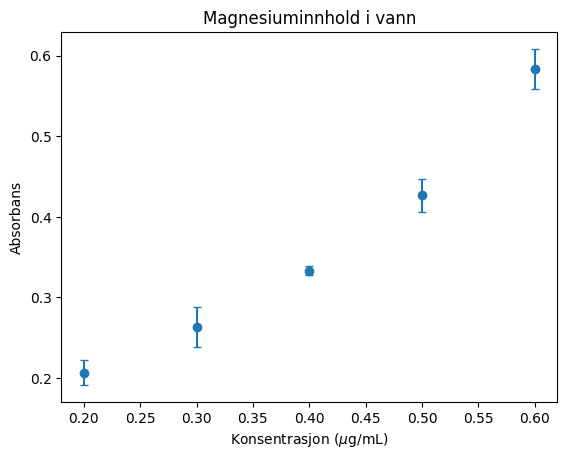

In [37]:
import numpy as np
import matplotlib.pyplot as plt

konsentrasjon = np.array([0.2, 0.3, 0.4, 0.5, 0.6])

absorbans = np.array([
    [0.21, 0.22, 0.19],
    [0.26, 0.29, 0.24],
    [0.33, 0.33, 0.34],
    [0.41, 0.42, 0.45],
    [0.56, 0.61, 0.58]
])

snitt = np.mean(absorbans, axis=1)
standardavvik = np.std(absorbans, axis=1, ddof=1)

plt.errorbar(
    konsentrasjon,
    snitt,
    yerr=standardavvik,
    fmt="o",
    capsize=3
)

plt.xlabel("Konsentrasjon ($\\mu$g/mL)")
plt.ylabel("Absorbans")
plt.title("Magnesiuminnhold i vann")
plt.show()

Den samme figuren kan brukes til å vise ulike mål på usikkerhet. Det eneste som endres, er argumentet `yerr`:

- `yerr=standardavvik`
- `yerr=standardfeil`
- `yerr=konfidensintervall`

Resten av koden er identisk.

## Statistikk med Pandas

Til nå har vi brukt NumPy til å beregne statistiske størrelser. Det passer godt når vi arbeider med én eller noen få måleserier. Når vi får **større datasett med mange rader og kolonner**, er det ofte mer praktisk å arbeide med en Pandas-DataFrame.

Pandas har metoder for de samme størrelsene vi allerede har brukt. For en numerisk kolonne kan vi for eksempel bruke `.mean()`, `.median()`, `.std()` og `.quantile()`. Metoden `.describe()` samler flere av de vanligste deskriptive størrelsene i én tabell.

I eksemplet nedenfor lager vi et syntetisk datasett som kan representere 200 uavhengige målinger av jern, kobber og sink i vannprøver. De tilfeldige tallene brukes bare for å få et større datasett å arbeide med.


In [ ]:
import pandas as pd

rng = np.random.default_rng(42)

data = pd.DataFrame({
    "jern_mg_L": rng.normal(5.0, 0.08, 200),
    "kobber_mg_L": rng.normal(0.80, 0.05, 200),
    "sink_mg_L": rng.normal(1.50, 0.10, 200)
})

data.describe()


`describe()` gir blant annet antall observasjoner (`count`), gjennomsnitt (`mean`), standardavvik (`std`), minimum, maksimum og 25-, 50- og 75-persentilen for hver numeriske kolonne.

Vi kan også hente ut én bestemt størrelse direkte. For eksempel:


In [ ]:
print("Gjennomsnitt:")
print(data.mean())

print("\nStandardavvik:")
print(data.std())

print("\nMedian:")
print(data.median())

Legg merke til at Pandas beregner statistikken **kolonnevis**. Hver kolonne representerer her én målt størrelse, og vi får derfor én middelverdi, ett standardavvik og én median for hvert stoff.

Dette er en viktig forskjell fra NumPy-eksemplet med feilstolper, der vi måtte angi `axis=1` fordi replikatene lå bortover radene i en todimensjonal array. I en DataFrame er dataene vanligvis organisert slik at **hver kolonne er en variabel og hver rad er én observasjon**, og Pandas-metodene arbeider som standard nedover hver kolonne.

Pandas erstatter altså ikke statistikken vi har lært. Det gir oss bare en praktisk måte å utføre de samme beregningene på når datasettet blir større og mer strukturert.


## Kort oppsummering

- Gjennomsnitt og standardavvik brukes ofte for gjentatte målinger av samme prøve.
- Median og IQR brukes ofte for skjeve fordelinger av mange forskjellige prøver.
- Persentiler beskriver hvor en verdi ligger i en sortert fordeling.
- RSD gjør det mulig å sammenlikne relativ presisjon ved ulike nivåer.
- Standardavvik beskriver enkeltmålinger. Standardfeil og konfidensintervall beskriver usikkerhet i gjennomsnittet.
- For større, tabellariske datasett kan Pandas beregne de samme størrelsene kolonnevis, blant annet med `describe()`, `mean()`, `std()` og `median()`.
- Statistiske mål må alltid tolkes sammen med rådataene og måten forsøket ble gjennomført på.

## Oppgaver

```{admonition} Oppgave 3.1 – persentiler
:class: tip
Kobberkonsentrasjonen i åtte jordprøver er `[12, 14, 15, 16, 18, 21, 29, 47]` mg/kg. Sorter dataene og beregn 25-, 50- og 75-persentilen. Forklar hvert resultat med ord. Hva betyr det for eksempel at en prøve ligger over 75-persentilen?
```

```{admonition} Oppgave 3.2 – velg riktig beskrivelse
:class: tip
Velg mellom gjennomsnitt og standardavvik eller median og IQR. Begrunn valget.

1. Seks uavhengige bestemmelser av klorid i den samme mineralvannsprøven.
2. Nitratkonsentrasjonen i 80 brønner, der noen få verdier er svært høye.
3. Blyinnholdet i jord fra ulike steder i et gammelt industriområde.
```

```{admonition} Oppgave 3.3 – følsomhet for en ekstrem verdi
:class: tip
Beregn gjennomsnitt, median, variasjonsbredde og IQR for `[4.91, 5.03, 4.98, 5.01, 5.07]`. Legg deretter til `5.80` og beregn størrelsene på nytt. Hvilke mål påvirkes mest, og hvorfor?
```

```{admonition} Oppgave 3.4 – standardavvik og RSD
:class: tip
Metode A gir et gjennomsnitt på 1,0 mg/L og et standardavvik på 0,05 mg/L. Metode B gir et gjennomsnitt på 100 mg/L og et standardavvik på 0,20 mg/L. Beregn RSD for begge. Hvilken metode har best relativ presisjon?
```

```{admonition} Oppgave 3.5 – hva beskriver størrelsen?
:class: tip
Forklar med egne ord hva standardavvik, standardfeil og 95 % konfidensintervall beskriver. Hvilken av størrelsene ville du brukt for å vise spredningen mellom fem enkeltmålinger? Hvilken ville du brukt for å vise usikkerheten i middelverdien?
```

```{admonition} Oppgave 3.6 – konfidensintervall
:class: tip
Beregn gjennomsnitt, standardavvik, standardfeil og 95 % konfidensintervall for `[12.42, 12.38, 12.45, 12.41, 12.39, 12.44]` mg/L. Rapporter resultatet med enhet. Forklar deretter to endringer i forsøket som kan gjøre intervallet smalere.
```

```{admonition} Oppgave 3.7 – hva er et replikat?
:class: tip
En student måler den samme løsningen ti ganger uten å ta kyvetten ut av instrumentet. En annen student lager ti løsninger uavhengig av hverandre og måler hver løsning én gang. Hvilke kilder til variasjon fanger de to forsøkene opp? Hvilket forsøk sier mest om presisjonen til hele analysemetoden?
```

```{admonition} Oppgave 3.8 – samlet case
:class: tip
Bruk `uvvis_calibration.csv`. Velg én standardkonsentrasjon og undersøk replikatene. Vis råmålingene, og beregn gjennomsnitt, standardavvik, RSD og 95 % konfidensintervall. Skriv til slutt tre–fire setninger der du forklarer hva standardavviket og konfidensintervallet forteller om målingene.
```